# ROC - AUC

ROC curve evaluates a classification model's ability to distinguish the positive class from the negative class across different decision thresholds. In multiclass problems, we typically compute one ROC curve for each class using a one-vs-rest approach. The Area Under the ROC Curve (AUC) summarizes this performance: an AUC of 1 indicates perfect separation, while an AUC of 0.5 indicates random guessing.

## Two Class

In [70]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [71]:
X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=2,
    cluster_std=5,
    random_state=42,
)

In [72]:
y.reshape(-1,1)

array([[0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
    

In [73]:
y_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1,1))

In [74]:
print(y_one_hot)

[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [68]:
y_one_hot = OneHotEncoder().fit_transform(y.reshape(-1,1))

In [69]:
print(y_one_hot)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 100 stored elements and shape (100, 2)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 0)	1.0
  (3, 1)	1.0
  (4, 1)	1.0
  (5, 0)	1.0
  (6, 1)	1.0
  (7, 1)	1.0
  (8, 0)	1.0
  (9, 0)	1.0
  (10, 0)	1.0
  (11, 1)	1.0
  (12, 0)	1.0
  (13, 0)	1.0
  (14, 1)	1.0
  (15, 1)	1.0
  (16, 1)	1.0
  (17, 1)	1.0
  (18, 1)	1.0
  (19, 0)	1.0
  (20, 1)	1.0
  (21, 1)	1.0
  (22, 1)	1.0
  (23, 1)	1.0
  (24, 1)	1.0
  :	:
  (75, 1)	1.0
  (76, 1)	1.0
  (77, 0)	1.0
  (78, 1)	1.0
  (79, 0)	1.0
  (80, 1)	1.0
  (81, 0)	1.0
  (82, 0)	1.0
  (83, 0)	1.0
  (84, 1)	1.0
  (85, 0)	1.0
  (86, 0)	1.0
  (87, 0)	1.0
  (88, 1)	1.0
  (89, 0)	1.0
  (90, 1)	1.0
  (91, 0)	1.0
  (92, 0)	1.0
  (93, 0)	1.0
  (94, 0)	1.0
  (95, 0)	1.0
  (96, 0)	1.0
  (97, 1)	1.0
  (98, 0)	1.0
  (99, 0)	1.0


In [75]:
model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [76]:
y_pred = model.predict_proba(X)
y_pred

array([[9.55178096e-01, 4.48219036e-02],
       [1.51032422e-02, 9.84896758e-01],
       [9.72405745e-01, 2.75942554e-02],
       [7.10884683e-02, 9.28911532e-01],
       [1.33949038e-01, 8.66050962e-01],
       [9.57455292e-01, 4.25447082e-02],
       [7.25600328e-02, 9.27439967e-01],
       [7.01849704e-01, 2.98150296e-01],
       [7.93834322e-01, 2.06165678e-01],
       [9.77256415e-01, 2.27435853e-02],
       [5.77550947e-01, 4.22449053e-01],
       [1.79603866e-01, 8.20396134e-01],
       [9.80057075e-01, 1.99429254e-02],
       [9.95958668e-01, 4.04133202e-03],
       [2.69165363e-01, 7.30834637e-01],
       [1.96325994e-01, 8.03674006e-01],
       [4.72420295e-01, 5.27579705e-01],
       [5.53661173e-01, 4.46338827e-01],
       [1.26631193e-02, 9.87336881e-01],
       [3.99471199e-01, 6.00528801e-01],
       [7.81298111e-03, 9.92187019e-01],
       [1.12618153e-01, 8.87381847e-01],
       [3.00416295e-03, 9.96995837e-01],
       [9.45512906e-03, 9.90544871e-01],
       [7.162815

In [77]:
#y_pred_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y_pred.reshape(-1,1))
#print(y_pred_one_hot)

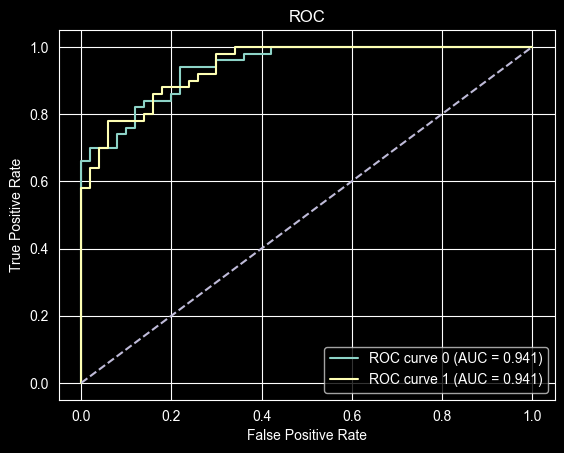

In [78]:
for i in range(2):
    fpr,tpr,thresholds = roc_curve(y_one_hot[:,i], y_pred[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'ROC curve {i} (AUC = %0.3f)' % roc_auc)

plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], '--')
plt.grid(True)
plt.legend()
plt.show()


In [79]:
print(auc(fpr,tpr))

0.9407999999999999


### MultiClasses

In [140]:
X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=4,
    cluster_std=5,
    random_state=42
)


In [141]:
y_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1,1))
print(y_one_hot)

[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1.

In [142]:
model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [143]:
y_pred = model.predict_proba(X)
y_pred

array([[6.26265668e-02, 5.97938855e-04, 5.37808436e-01, 3.98967059e-01],
       [3.44555632e-04, 9.67307408e-03, 9.89911767e-01, 7.06029182e-05],
       [5.90988772e-01, 7.56166412e-03, 7.21419029e-04, 4.00728145e-01],
       [3.47318304e-04, 4.45737494e-02, 9.55050629e-01, 2.83036638e-05],
       [4.36354740e-01, 3.32956304e-03, 2.14445700e-03, 5.58171240e-01],
       [4.66442090e-04, 1.02855703e-04, 9.97796220e-01, 1.63448249e-03],
       [1.36078579e-01, 8.60830507e-01, 3.81607436e-04, 2.70930611e-03],
       [1.81047219e-01, 8.05506047e-01, 5.64278851e-03, 7.80394627e-03],
       [2.05574331e-01, 7.87835295e-01, 7.36609107e-04, 5.85376516e-03],
       [3.45277145e-01, 1.25698605e-03, 1.34408282e-03, 6.52121786e-01],
       [5.72041942e-01, 1.12459639e-02, 2.78825526e-03, 4.13923839e-01],
       [2.41056874e-01, 5.77444326e-02, 5.38863036e-01, 1.62335658e-01],
       [2.52373077e-02, 4.60115330e-02, 9.19113849e-01, 9.63731026e-03],
       [6.76661383e-02, 3.67717644e-01, 5.55135361e

In [144]:
#y_pred_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y_pred.reshape(-1,1))

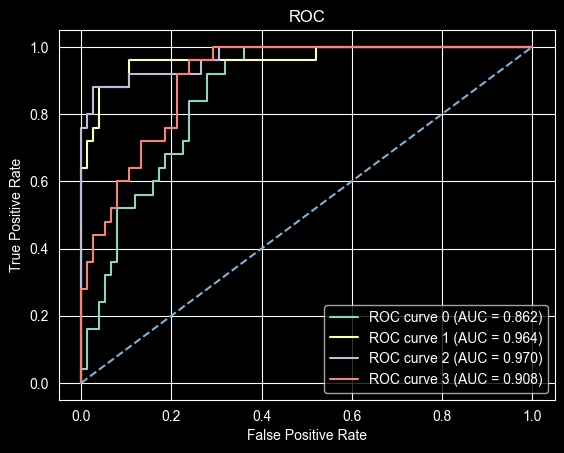

In [145]:
for i in range(4):
    fpr,tpr,thresholds = roc_curve(y_one_hot[:,i], y_pred[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr, tpr, label=f'ROC curve {i} (AUC = %0.3f)' % roc_auc)

plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], '--')
plt.grid(True)
plt.legend()
plt.show()



### Another way for multiClasses (Common way)

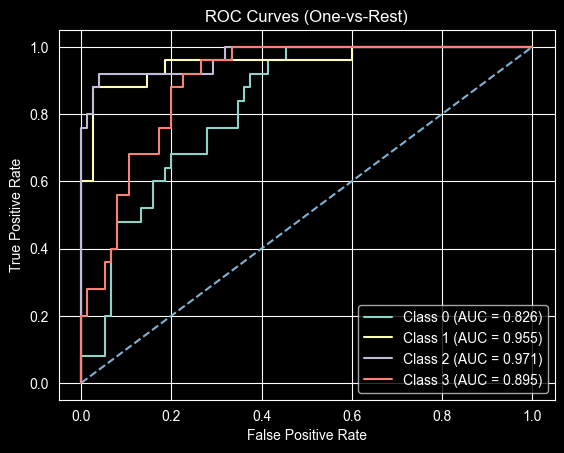

In [146]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder

# One-hot encode labels
y_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1, 1))

# Train One-vs-Rest Logistic Regression
model = OneVsRestClassifier(LogisticRegression())
model.fit(X, y)

# Predicted probabilities
y_pred = model.predict_proba(X)

# ROC for each class
for i in range(y_one_hot.shape[1]):
    fpr, tpr, _ = roc_curve(y_one_hot[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], '--')
plt.title('ROC Curves (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.legend()
plt.show()

### without ONEHOEENCODER

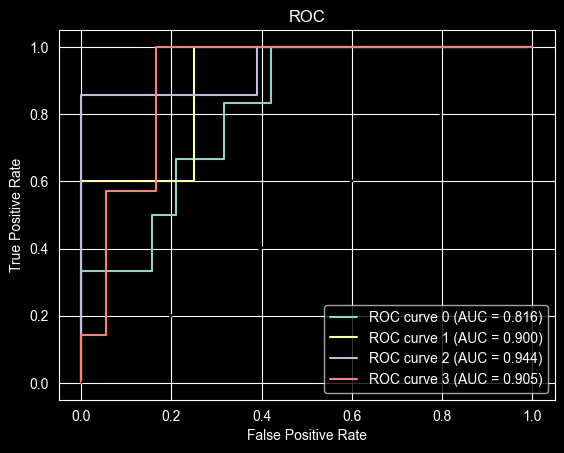

In [149]:
from sklearn.preprocessing import label_binarize

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = OneVsRestClassifier(LogisticRegression())
model.fit(X_train, y_train)

y_score = model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=model.classes_)

for i in range(len(model.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve {i} (AUC = %0.3f)' % roc_auc)

plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--')
plt.grid(True)
plt.legend()
plt.show()


In [151]:
y_test_bin

array([[0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 1, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [0, 0, 1, 0]])

## Multiple Models

In [113]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
models = {
    'Logistic Regression': LogisticRegression(),

    'Random Forest': RandomForestClassifier(n_estimators=100),
}

In [115]:
for name , model in models.items():
    model.fit(X_train, y_train)

In [116]:
y_pred_lg = models['Logistic Regression'].predict_proba(X_test)

In [117]:
y_pred_rf = models['Random Forest'].predict_proba(X_test)

In [118]:
y_pred_lg

array([[3.51112014e-01, 6.48887986e-01],
       [1.32095334e-01, 8.67904666e-01],
       [5.24593248e-01, 4.75406752e-01],
       [1.47364774e-01, 8.52635226e-01],
       [4.45002438e-02, 9.55499756e-01],
       [9.45724448e-01, 5.42755520e-02],
       [7.82234155e-01, 2.17765845e-01],
       [1.78147680e-01, 8.21852320e-01],
       [2.54573593e-01, 7.45426407e-01],
       [6.10423342e-01, 3.89576658e-01],
       [4.93832440e-02, 9.50616756e-01],
       [4.31275944e-01, 5.68724056e-01],
       [9.95203655e-01, 4.79634477e-03],
       [5.13966827e-01, 4.86033173e-01],
       [2.80691771e-01, 7.19308229e-01],
       [7.96254746e-01, 2.03745254e-01],
       [9.23952966e-01, 7.60470342e-02],
       [5.54754830e-02, 9.44524517e-01],
       [1.13056057e-01, 8.86943943e-01],
       [5.28455143e-01, 4.71544857e-01],
       [7.44101488e-03, 9.92558985e-01],
       [7.86898615e-01, 2.13101385e-01],
       [9.51331807e-01, 4.86681931e-02],
       [9.10512490e-01, 8.94875102e-02],
       [2.454074

In [119]:
y_pred_rf

array([[0.3 , 0.7 ],
       [0.27, 0.73],
       [0.81, 0.19],
       [0.08, 0.92],
       [0.02, 0.98],
       [0.97, 0.03],
       [0.83, 0.17],
       [0.15, 0.85],
       [0.39, 0.61],
       [0.74, 0.26],
       [0.1 , 0.9 ],
       [0.42, 0.58],
       [0.91, 0.09],
       [0.21, 0.79],
       [0.46, 0.54],
       [0.84, 0.16],
       [0.89, 0.11],
       [0.14, 0.86],
       [0.17, 0.83],
       [0.51, 0.49],
       [0.1 , 0.9 ],
       [0.79, 0.21],
       [0.84, 0.16],
       [0.86, 0.14],
       [0.06, 0.94],
       [0.97, 0.03],
       [0.08, 0.92],
       [0.22, 0.78],
       [0.87, 0.13],
       [0.05, 0.95],
       [0.53, 0.47],
       [0.04, 0.96],
       [0.24, 0.76],
       [0.94, 0.06],
       [0.7 , 0.3 ],
       [0.84, 0.16],
       [0.97, 0.03],
       [0.65, 0.35],
       [0.97, 0.03],
       [0.75, 0.25],
       [0.94, 0.06],
       [0.18, 0.82],
       [0.96, 0.04],
       [0.79, 0.21],
       [0.18, 0.82],
       [0.96, 0.04],
       [0.09, 0.91],
       [0.97,

In [120]:
y_test_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y_test.reshape(-1,1))

In [121]:
y_test_one_hot

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.

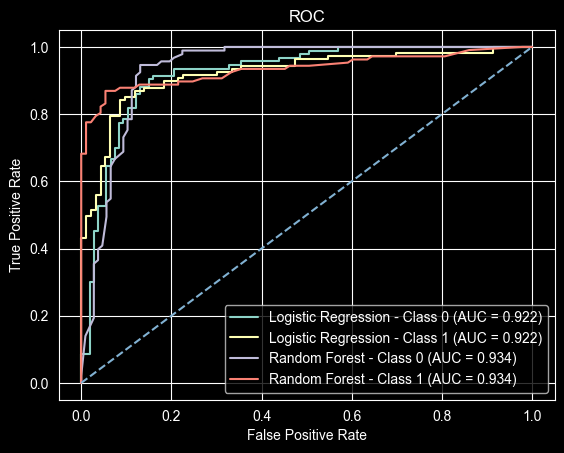

In [137]:
for name, i in zip(
    ['Logistic Regression', 'Random Forest'],
    [y_pred_lg, y_pred_rf]
):
    for j in range(2):

        fpr, tpr, thresholds = roc_curve(
            y_test_one_hot[:, j],
            i[:, j]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'{name} - Class {j} (AUC = {roc_auc:.3f})'
        )


plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], '--')
plt.grid(True)
plt.legend()
plt.show()

## Concepts

[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


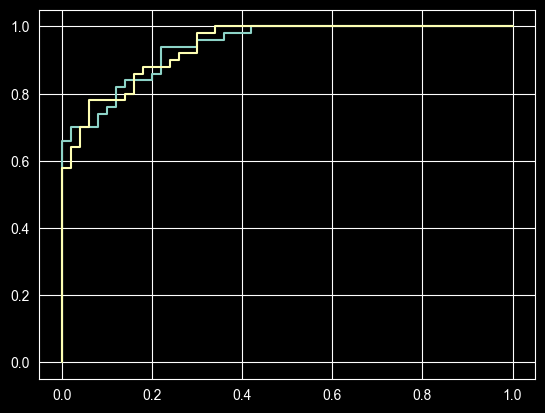

In [155]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=2,
    cluster_std=5,
    random_state=42,
)
y.reshape(-1, 1)
y_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1, 1))
print(y_one_hot)

model = LogisticRegression()
model.fit(X, y)
y_pred = model.predict_proba(X)
y_pred
#y_pred_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y_pred.reshape(-1,1))
#print(y_pred_one_hot)
for i in range(2):
    fpr, tpr, thresholds = roc_curve(y_one_hot[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve {i} (AUC = %0.3f)' % roc_auc)


In [177]:
thresholds


array([           inf, 9.99600225e-01, 8.82523501e-01, 8.73943278e-01,
       8.41669299e-01, 8.26742956e-01, 8.03674006e-01, 7.72571354e-01,
       6.92630413e-01, 6.57063430e-01, 6.48389046e-01, 6.00528801e-01,
       4.46338827e-01, 4.22449053e-01, 4.13815888e-01, 3.50718629e-01,
       3.30949013e-01, 3.05023151e-01, 2.98150296e-01, 2.81720496e-01,
       2.44791618e-01, 1.68860355e-01, 1.66599536e-01, 9.30867592e-05])

In [178]:
fpr

array([0.  , 0.  , 0.  , 0.02, 0.02, 0.04, 0.04, 0.06, 0.06, 0.14, 0.14,
       0.16, 0.16, 0.18, 0.18, 0.24, 0.24, 0.26, 0.26, 0.3 , 0.3 , 0.34,
       0.34, 1.  ])

In [179]:
tpr

array([0.  , 0.02, 0.58, 0.58, 0.64, 0.64, 0.7 , 0.7 , 0.78, 0.78, 0.8 ,
       0.8 , 0.86, 0.86, 0.88, 0.88, 0.9 , 0.9 , 0.92, 0.92, 0.98, 0.98,
       1.  , 1.  ])

In [180]:
df=zip(thresholds,fpr,tpr)

In [181]:
import pandas as pd
df = pd.DataFrame(df,columns=['thresholds','fpr','tpr'])

In [182]:
df

,thresholds,fpr,tpr
0,inf,0.00,0.00
1,0.999600,0.00,0.02
2,0.882524,0.00,0.58
3,0.873943,0.02,0.58
4,0.841669,0.02,0.64
5,0.826743,0.04,0.64
6,0.803674,0.04,0.70
7,0.772571,0.06,0.70
8,0.692630,0.06,0.78
9,0.657063,0.14,0.78


In [186]:
fpr, tpr, thresholds = roc_curve(y_one_hot[:,1], y_pred[:,1])

# Youden's J statistic
J = tpr - fpr

# index of best threshold
best_index = np.argmax(J)

best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best TPR:", tpr[best_index])
print("Best FPR:", fpr[best_index])

Best threshold: 0.6926304131471819
Best TPR: 0.78
Best FPR: 0.06
